In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix





In [2]:

df = pd.read_csv('ecommerce_bigdata.csv')  # Replace 'your_dataset.csv' with

In [3]:

df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [4]:

df.isnull().sum()

TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64

In [5]:

df.describe()

,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


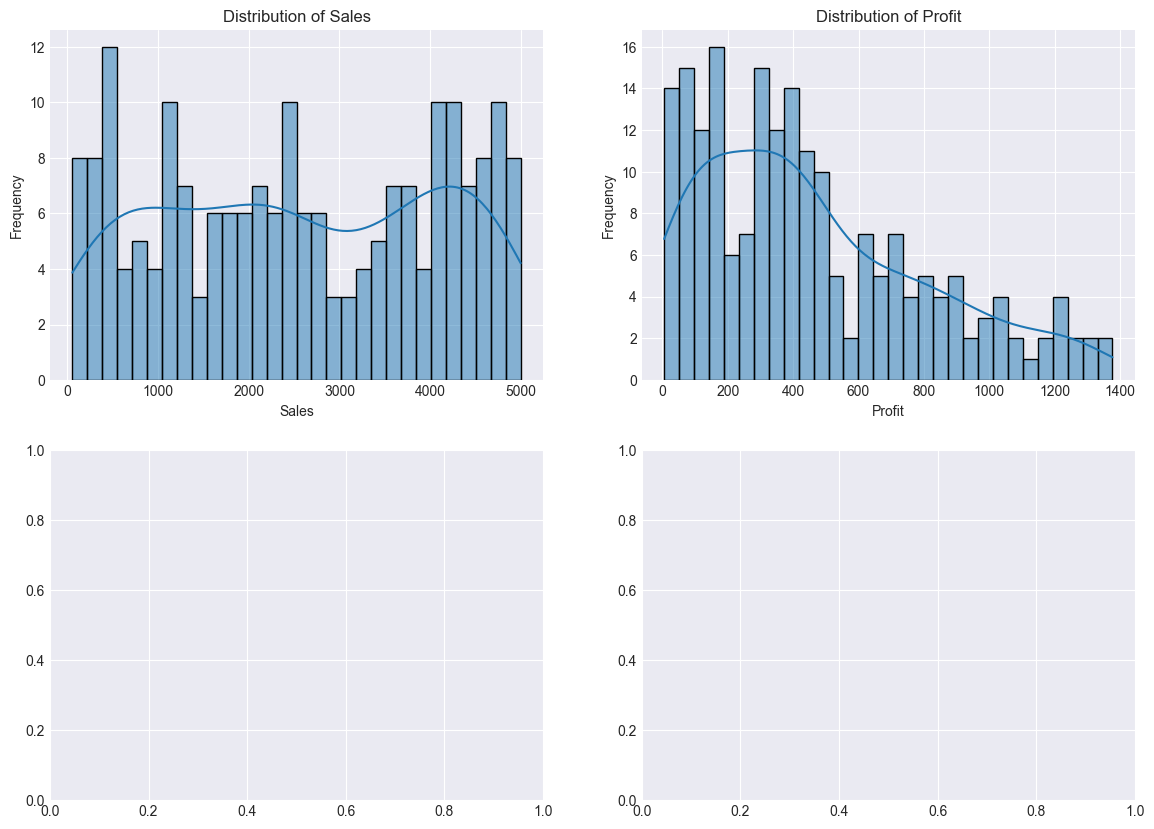

In [6]:

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sales')   
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Profit')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')

plt.show()



In [7]:
# Step 4: 3. Feature Engineering: Selecting and creating relevant features that will help the model learn better.
# Create a copy of the original dataframe to avoid modifying it directly
df_processed = df.copy()


# Convert Date to datetime format and extract relevant features (e.g., year, month, day)
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['Weekday'] = df_processed['Date'].dt.weekday

In [8]:
# Encoded categorical variables (text → numbers)



label_encoder = {}

categorical_columns = ['Region', 'ProductCategory', 'CustomerType']  # Replace with your categorical columns
for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col + '_Encoded'] = le.fit_transform(df_processed[col])
    label_encoder[col] = le  # Store the label encoder for future use
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')


Encoded Region: {'Central': np.int64(0), 'Eastern': np.int64(1), 'Northern': np.int64(2), 'Western': np.int64(3)}
Encoded ProductCategory: {'Beverages': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Food': np.int64(3), 'Household Products': np.int64(4)}
Encoded CustomerType: {'Online': np.int64(0), 'Retail': np.int64(1), 'Wholesale': np.int64(2)}


In [9]:
# Drop the original categorical columns after encoding and TransactionID (Not useful for prediction)
df_processed.drop(['TransactionID', 'Date', 'Region', 'ProductCategory', 'CustomerType'], axis=1, inplace=True)

print("Processed DataFrame after encoding and dropping unnecessary columns:")
df_processed.head()

Processed DataFrame after encoding and dropping unnecessary columns:


,Sales,Profit,Month,Day,Weekday,Region_Encoded,ProductCategory_Encoded,CustomerType_Encoded
0,4924,359.44,6,16,1,1,2,2
1,3283,944.32,2,12,3,0,2,1
2,4049,967.10,3,1,6,2,3,0
3,4331,434.57,6,3,2,3,4,0
4,3283,340.48,1,21,2,3,4,1


In [10]:
# Step 5: Split the dataset into training and testing sets
# Define features and target variable for regression task (predicting profit)
# Regression Task: Predicting Profit based on Sales
print('Regression: Predicting Profit based on Sales')

# Prepare the features (X) and target variable (y) for regression
X_reg = df_processed.drop('Sales', axis=1)  # Features (all columns except 'Profit') Independent variables
y_reg = df_processed['Profit']  # Target variable (Profit) Dependent variable

# Split the dataset into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


print(f'Regression Data Split: ')
print(f"Training set size: {X_train_reg.shape[0]} samples")
print(f"Testing set size: {X_test_reg.shape[0]} samples")


Regression: Predicting Profit based on Sales
Regression Data Split: 
Training set size: 160 samples
Testing set size: 40 samples


In [11]:
# Train multiple regression models and evaluate their performance
# 1. Linear Regression
# 2. Decision Tree Regressor
# 3. Random Forest Regressor

regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

print("\nRegression Model Evaluation:")
regression_results = {}

for name, model in regression_models.items():
    # Train the model
    model.fit(X_train_reg, y_train_reg)
    
    # Make predictions on the test set
    y_pred_reg = model.predict(X_test_reg)
    
    # Evaluate the model and calculate RMSE and R-squared
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    regression_results[name] = {'RMSE': rmse, 'R-squared': r2}
    
    print(f"{name}: RMSE = {rmse:.4f}, R-squared = {r2:.4f}")

    # Store results 
    regression_results[name] = {
        'model': model,
        'RMSE': rmse,
        'mse': mean_squared_error(y_test_reg, y_pred_reg),
        'R-squared': r2,
        'predicted_profit': y_pred_reg
    }

    print(f"{name} model trained and evaluated successfully.")
    print(f"Mean Squared Error (MSE): {regression_results[name]['mse']:.2f}")
    print(f"Root Mean Squared Error (RMSE): {regression_results[name]['RMSE']:.4f}")
    print(f"R-squared: {regression_results[name]['R-squared']:.4f}")
    print(f"Interpretation: {regression_results[name]['predicted_profit'][:5]}")  # Display first 5 predictions


Regression Model Evaluation:
Linear Regression: RMSE = 0.0000, R-squared = 1.0000
Linear Regression model trained and evaluated successfully.
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.0000
R-squared: 1.0000
Interpretation: [ 41.94 905.95 496.96 712.17 587.69]
Decision Tree Regressor: RMSE = 23.4780, R-squared = 0.9951
Decision Tree Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 551.21
Root Mean Squared Error (RMSE): 23.4780
R-squared: 0.9951
Interpretation: [ 40.04 899.24 510.68 725.   567.64]
Random Forest Regressor: RMSE = 6.6446, R-squared = 0.9996
Random Forest Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 44.15
Root Mean Squared Error (RMSE): 6.6446
R-squared: 0.9996
Interpretation: [ 42.0606 901.4156 503.2668 716.7321 588.3444]


In [12]:
# Assignment 1: Classification Task: Predicting Customer Type based on transaction data

# Prepare features (X) and target (y) for classification
X_clf = df_processed.drop("CustomerType_Encoded", axis=1)
y_clf = df_processed["CustomerType_Encoded"]

# Split into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled = scaler.transform(X_test_clf)

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(random_state=42)
}

print("\nClassification Model Evaluation:")
for name, model in classifiers.items():
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train_clf
    X_te = X_test_scaled if name == "Logistic Regression" else X_test_clf
    model.fit(X_tr, y_train_clf)
    y_pred = model.predict(X_te)
    print(f"\n{name}:")
    print(f"  Accuracy : {accuracy_score(y_test_clf, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test_clf, y_pred, average="weighted", zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_test_clf, y_pred, average="weighted", zero_division=0):.4f}")
    print(f"  F1-Score : {f1_score(y_test_clf, y_pred, average="weighted", zero_division=0):.4f}")



Classification Model Evaluation:

Logistic Regression:
  Accuracy : 0.2750
  Precision: 0.2822
  Recall   : 0.2750
  F1-Score : 0.2739

Decision Tree Classifier:
  Accuracy : 0.2500
  Precision: 0.3069
  Recall   : 0.2500
  F1-Score : 0.2581

Random Forest Classifier:
  Accuracy : 0.2000
  Precision: 0.2473
  Recall   : 0.2000
  F1-Score : 0.2149


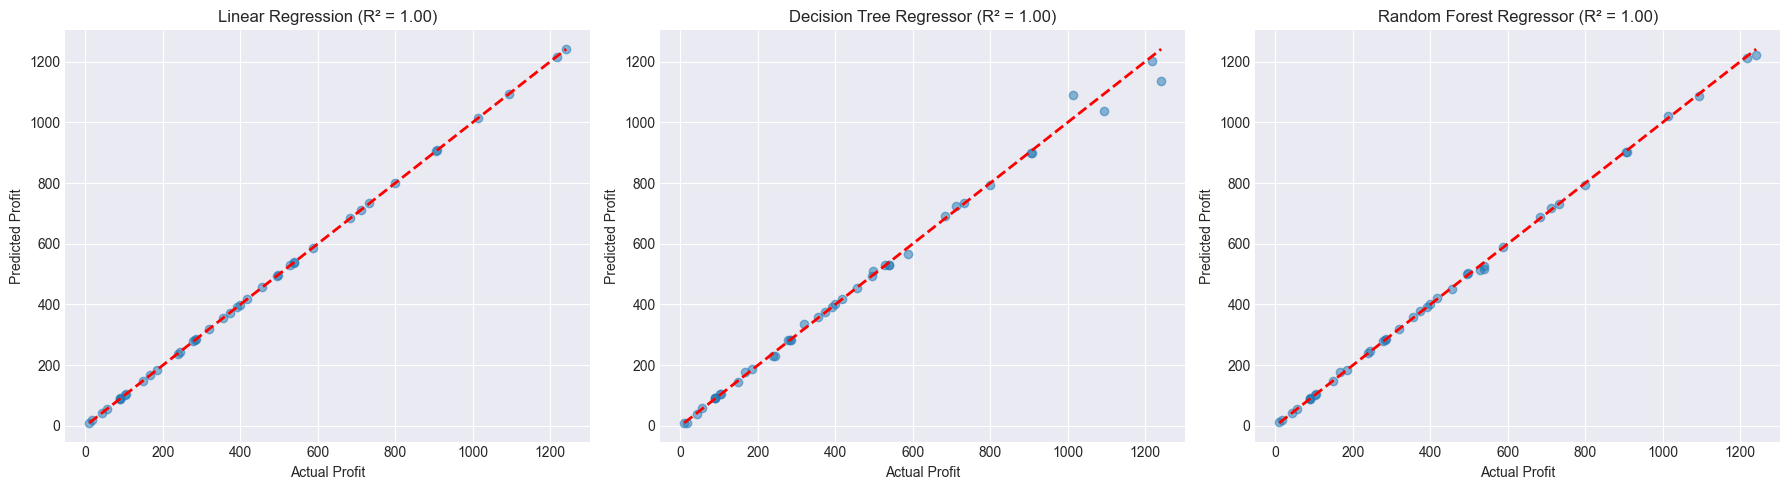

Regression models evaluated and visualized successfully.


<Figure size 640x480 with 0 Axes>

In [13]:
# Visualize the results and interpret the findings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, result) in enumerate(regression_results.items()):
    axes[i].scatter(y_test_reg, result['predicted_profit'], alpha=0.5)
    axes[i].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
    axes[i].set_title(f"{name} (R² = {result['R-squared']:.2f})")
    axes[i].set_xlabel('Actual Profit')
    axes[i].set_ylabel('Predicted Profit')

plt.tight_layout()
plt.show()
print("Regression models evaluated and visualized successfully.")
plt.savefig('regression_model_evaluation.png')  # Save the figure as a PNG file